In [1]:
import os, sys
import torch
import argparse
import numpy as np
import torch.utils.data
from easydict import EasyDict as edict
from timeit import default_timer as timer
from tqdm import tqdm

from utils.eval import Metric
from utils.gpu_dispatch import GPU
from utils.common_utils import dir_check, to_device, ws, unfold_dict, dict_merge, GpuId2CudaId, Logger

from algorithm.dataset import CleanDataset, TrafficDataset
from algorithm.diffstg.model import DiffSTG, save2file

import matplotlib.pyplot as plt

In [2]:
trained_model_path = './output/model/ewz_preprocessed_1day_1hour_50epoch.dm4stg'

DATA_path = './data/dataset/EWZ_preprocessed/'
flow_path = os.path.join(DATA_path, 'flow.npy')
adj_path = os.path.join(DATA_path, 'adj.npy')

In [3]:
flow = np.load(flow_path)
adj = np.load(adj_path) 

flow.shape

(52888, 50, 1)

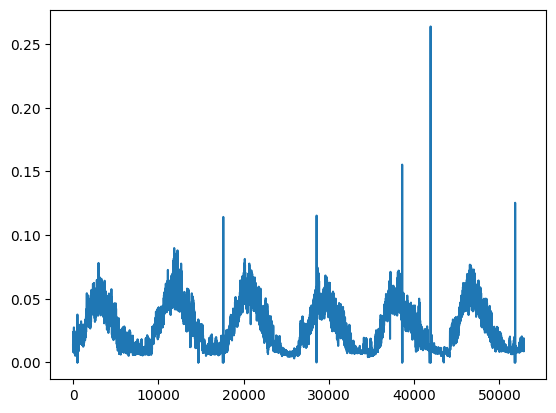

In [7]:
T = flow.shape[0]
sensor_idx = 2
plt.plot(range(T), flow[:,sensor_idx,0])

In [28]:
config = edict()
config.model = edict()

T_p = 1
T_h = 24
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

config.n_samples = 2
config.device = device

config.model.T_p = T_p
config.model.T_h = T_h
config.model.V = 50
config.model.F = 1
config.model.week_len = 7
config.model.day_len = 24
config.model.device = device
config.model.d_h = 32

# config for diffusion model
config.model.N = 200
config.model.sample_steps = 200
config.model.epsilon_theta = 'UGnet'
config.model.is_label_condition = True
config.model.beta_end = 0.02
config.model.beta_schedule = 'quad'
config.model.sample_strategy = 'ddpm'


# config for UGnet
config.model.channel_multipliers = [1, 2]  # The list of channel numbers at each resolution.
config.model.supports_len = 2

# training config
config.model_name = 'DiffSTG'

config.model.A = adj

In [29]:
model = torch.load(trained_model_path, map_location=config.model.device, weights_only=False)

In [30]:
config.data = edict()
config.data.name = 'EWZ_preprocessed'
config.data.feature_file = os.path.join(DATA_path, 'flow.npy')
config.data.spatial = os.path.join(DATA_path, 'adj.npy')
config.data.val_start_idx = int(T * 0.7)
config.data.test_start_idx = int(T * 0.85)
config.data.points_per_hour = 1

clean_data = CleanDataset(config)

In [31]:
test_dataset = TrafficDataset(clean_data, (config.data.test_start_idx + config.model.T_p, -1), config)
test_loader = torch.utils.data.DataLoader(test_dataset, 64, shuffle=False)

sample num: 7933


In [32]:
def predict(model, data_loader, config, clean_data, mode='Test'):

    y_pred, y_true = [], []
    metrics_future = Metric(T_p=config.model.T_p)
    metrics_history = Metric(T_p=config.model.T_h)
    model.eval()

    samples, targets = [], []
    for i, batch in enumerate(data_loader):

        future, history, pos_w, pos_d = to_device(batch, config.device) # target:(B,T,V,1), history:(B,T,V,1), pos_w: (B,1), pos_d:(B,T,1)

        x = torch.cat((history, future), dim=1).to(config.device)  # in cpu (B, T, V, F), T =  T_h + T_p
        x_masked = torch.cat((history, torch.zeros_like(future)), dim=1).to(config.device)  # (B, T, V, F)
        targets.append(x.cpu())
        x = x.transpose(1, 3)  # (B, F, V, T)
        x_masked = x_masked.transpose(1, 3)  # (B, F, V, T)

        n_samples = 1 if mode == 'Val' else config.n_samples
        # n_samples = config.n_samples
        x_hat = model((x_masked, pos_w, pos_d), n_samples) # (B, n_samples, F, V, T)
        samples.append(x_hat.transpose(2,4).cpu())

        if x_hat.shape[-1] != (config.model.T_h + config.model.T_p): x_hat = x_hat.transpose(2,4)
        # assert x.shape == x_hat.shape, f"shape of x ({x.shape}) does not equal to shape of x_hat ({x_hat.shape})"
        x, x_hat= clean_data.reverse_normalization(x), clean_data.reverse_normalization(x_hat)
        x_hat = x_hat.detach()
        f_x, f_x_hat = x[:,:,:,-config.model.T_p:], x_hat[:,:,:,:,-config.model.T_p:] # future

        _y_true_ = f_x.transpose(1, 3).cpu().numpy()  # y_true: (B, T_p, V, D)
        _y_pred_ = f_x_hat.transpose(2, 4).cpu().numpy() # y_pred: (B, n_samples, T_p, V, D)
        _y_pred_ = np.clip(_y_pred_, 0, np.inf)
        metrics_future.update_metrics(_y_true_, _y_pred_)

        y_pred.append(_y_pred_)
        y_true.append(_y_true_)

        h_x, h_x_hat = x[:, :, :, :config.model.T_h], x_hat[:, :, :, :,  :config.model.T_h]
        _y_true_ = h_x.transpose(1, 3).cpu().numpy()  # y_true: (B, T_p, V, D)
        _y_pred_ = h_x_hat.transpose(2, 4).cpu().numpy()
        _y_pred_ = np.clip(_y_pred_, 0, np.inf)
        metrics_history.update_metrics(_y_true_, _y_pred_)

    y_true = np.concatenate(y_true, axis=0)
    y_pred = np.concatenate(y_pred, axis=0)


    if mode == 'test': # save the prediction result to file
        samples = torch.cat(samples, dim=0)[:50]
        targets = torch.cat(targets, dim=0)[:50]


    torch.cuda.empty_cache()
    return y_true, y_pred

In [33]:
y_true, y_pred = predict(model, test_loader, config, clean_data, mode='test')

AssertionError: Torch not compiled with CUDA enabled